Movie Hit or Flop Prediction

This project predicts whether a movie will be a **Hit** or **Flop** based on IMDb data.
We use a machine learning model (Random Forest Classifier) trained on features such as:

- IMDB Rating
- Meta Score
- Runtime
- Number of Votes
- Gross Earnings
- Released Year
- Primary Genre

 Objective:
A movie is considered a **Hit** if:
- `IMDB_Rating >= 7`
- `Gross >= 50 million`

Otherwise, it's classified as a **Flop**.

Dataset:
- Source: IMDb 1000 Movies Metadata (from Kaggle)
- Format: CSV



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib

import warnings
warnings.filterwarnings("ignore")



In [2]:
df = pd.read_csv("data/movies_metadata.csv", low_memory=False)
df.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [3]:
print("Dataset shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
df.info()
df.describe()

Dataset shape: (1000, 16)

Column names:
 ['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate', 'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director', 'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   obj

,IMDB_Rating,Meta_score,No_of_Votes
count,1000.000000,843.000000,1.000000e+03
mean,7.949300,77.971530,2.736929e+05
std,0.275491,12.376099,3.273727e+05
min,7.600000,28.000000,2.508800e+04
25%,7.700000,70.000000,5.552625e+04
50%,7.900000,79.000000,1.385485e+05
75%,8.100000,87.000000,3.741612e+05
max,9.300000,100.000000,2.343110e+06


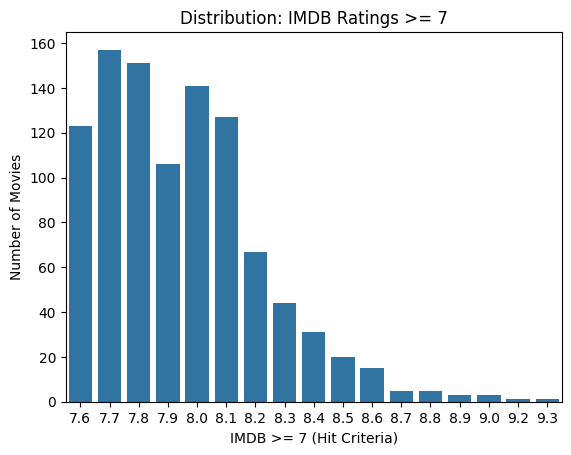

In [6]:
sns.countplot(x='IMDB_Rating', data=df)
plt.title("Distribution: IMDB Ratings >= 7")
plt.xlabel("IMDB >= 7 (Hit Criteria)")
plt.ylabel("Number of Movies")
plt.show()


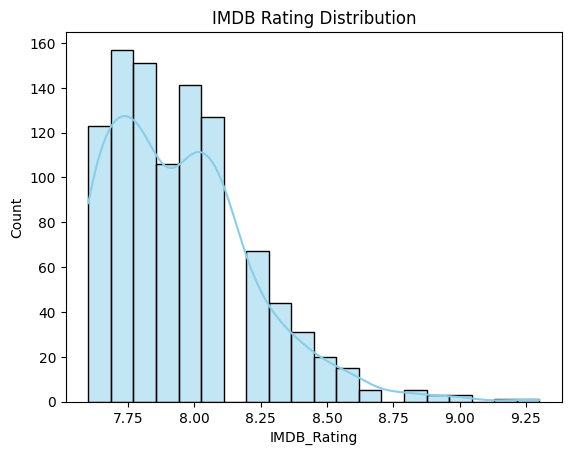

In [7]:
sns.histplot(df['IMDB_Rating'], kde=True, bins=20, color='skyblue')
plt.title("IMDB Rating Distribution")
plt.show()


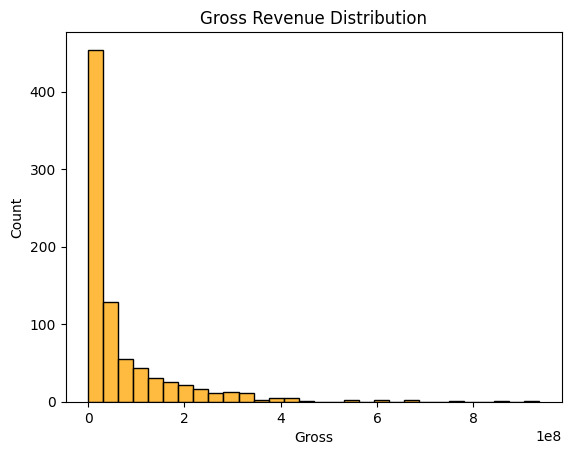

In [8]:
df['Gross'] = pd.to_numeric(df['Gross'].astype(str).str.replace(',', ''), errors='coerce')
sns.histplot(df['Gross'], bins=30, color='orange')
plt.title("Gross Revenue Distribution")
plt.show()


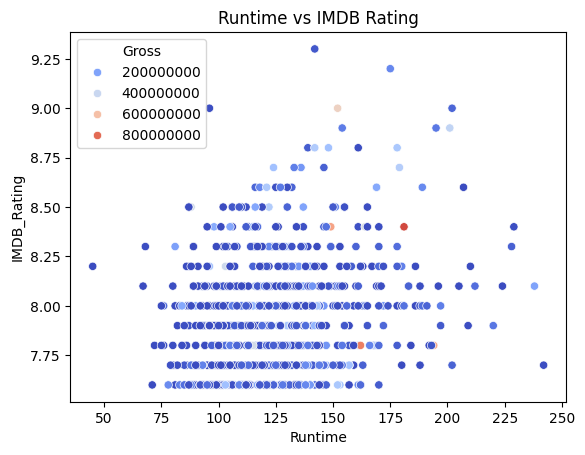

In [9]:
df['Runtime'] = pd.to_numeric(df['Runtime'].astype(str).str.replace(' min', ''), errors='coerce')
sns.scatterplot(data=df, x='Runtime', y='IMDB_Rating', hue='Gross', palette='coolwarm')
plt.title("Runtime vs IMDB Rating")
plt.show()


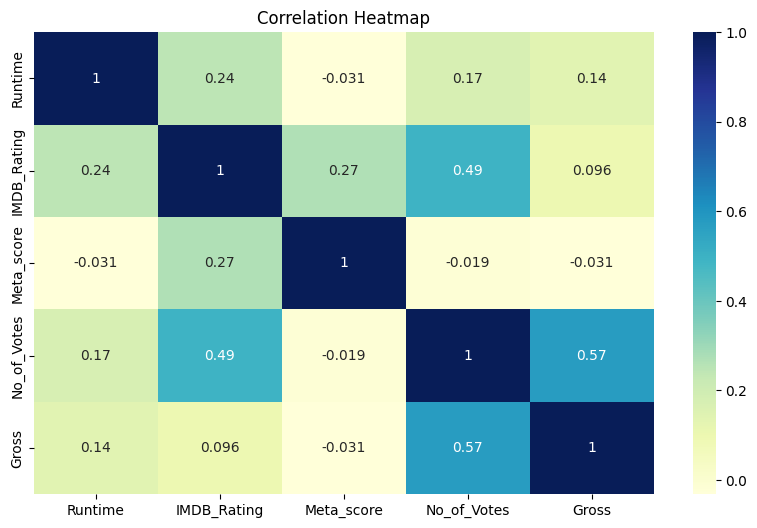

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="YlGnBu")
plt.title("Correlation Heatmap")
plt.show()


In [11]:
# Clean Runtime
df['Runtime'] = df['Runtime'].fillna(df['Runtime'].median())

# Clean Meta_score
df['Meta_score'] = df['Meta_score'].fillna(df['Meta_score'].median())

# Clean Gross
df['Gross'] = df['Gross'].fillna(0)

# Clean Released_Year
df['Released_Year'] = pd.to_numeric(df['Released_Year'], errors='coerce')
df['Released_Year'] = df['Released_Year'].fillna(df['Released_Year'].median()).astype(int)



In [12]:
# Create target variable
df['hit'] = ((df['IMDB_Rating'] >= 7) & (df['Gross'] >= 50000000)).astype(int)
print("Hit/Flop Distribution:\n", df['hit'].value_counts())

# Extract primary genre
df['Primary_Genre'] = df['Genre'].str.split(',').str[0]

# One-hot encoding
df = pd.get_dummies(df, columns=['Primary_Genre'], drop_first=True)


Hit/Flop Distribution:
 hit
0    702
1    298
Name: count, dtype: int64


In [13]:
# Feature list
features = ['IMDB_Rating', 'Meta_score', 'Runtime', 'No_of_Votes', 'Gross', 'Released_Year'] + \
           [col for col in df.columns if 'Primary_Genre_' in col]

X = df[features]
y = df['hit']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)



In [14]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       140
           1       1.00      1.00      1.00        60

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [17]:
joblib.dump(clf, 'movie_hit_model.joblib')



['movie_hit_model.joblib']

In [18]:
def predict_movie_hit(IMDB_Rating, Meta_score, Runtime, No_of_Votes, Gross, Released_Year, Genre):
    # Load model
    clf = joblib.load('movie_hit_model.joblib')

    # Base row
    movie_df = pd.DataFrame({
        'IMDB_Rating': [IMDB_Rating],
        'Meta_score': [Meta_score],
        'Runtime': [Runtime],
        'No_of_Votes': [No_of_Votes],
        'Gross': [Gross],
        'Released_Year': [Released_Year]
    })

    # Add all genre columns with 0
    for col in [c for c in clf.feature_names_in_ if 'Primary_Genre_' in c]:
        movie_df[col] = 0

    # Set genre column to 1
    genre_col = f'Primary_Genre_{Genre}'
    if genre_col in movie_df.columns:
        movie_df[genre_col] = 1

    pred = clf.predict(movie_df)[0]
    return "Hit" if pred == 1 else "Flop"

# Example
predict_movie_hit(IMDB_Rating=5.0, Meta_score=25, Runtime=40,
                  No_of_Votes=500, Gross=10000,
                  Released_Year=2003, Genre="Action")


'Flop'